<a href="https://colab.research.google.com/github/indahsarikurniawati/tugas-ml/blob/main/UTS_ML_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# IMPORT LIBRARY
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# LOAD DATA
train = pd.read_csv("/content/data_training.csv")
test = pd.read_csv("/content/data_testing.csv")

train.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [42]:
# CEK MISSING VALUE
print("Jumlah missing value di setiap kolom:")
print(train.isnull().sum())

Jumlah missing value di setiap kolom:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Dari hasil pengecekan missing value menggunakan isnull().sum(), diketahui bahwa seluruh variabel pada dataset memiliki nilai 0, yang berarti tidak terdapat data yang hilang pada semua kolom. Hal ini menunjukkan bahwa dataset sudah dalam kondisi bersih dan lengkap, sehingga tidak diperlukan proses penanganan missing value seperti imputasi atau penghapusan data. Dengan demikian, data dapat langsung digunakan untuk tahap analisis dan pemodelan tanpa perlu proses pembersihan tambahan terkait nilai yang hilang.

In [10]:
# EDA SEDERHANA
print(train.info())
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None
fixed acidity           0
volatile acidity        0
citric acid          

Dari hasil eksplorasi data menggunakan info() dan pengecekan missing value, diperoleh beberapa informasi sebagai berikut:

Dataset wine quality memiliki total 857 observasi dengan 13 variabel, yang terdiri dari 11 variabel numerik bertipe float64 dan 2 variabel bertipe integer, yaitu quality sebagai target dan Id sebagai identitas data.

Seluruh variabel memiliki 857 non-null values, yang menunjukkan bahwa tidak terdapat missing value pada dataset. Hal ini berarti data sudah bersih dan tidak memerlukan proses imputasi atau penghapusan data hilang.

Dari sisi struktur data:

Variabel fitur terdiri dari karakteristik kimia anggur seperti fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, hingga alcohol.
Variabel target quality berupa data diskrit (integer) yang menunjukkan tingkat kualitas anggur.

Selain itu, kolom Id merupakan identitas unik setiap sampel dan tidak berpengaruh terhadap proses prediksi, sehingga akan dihapus pada tahap preprocessing.

In [40]:
# FEATURE SCALING
# Pada kasus ini tidak dilakukan scaling karena Random Forest tidak sensitif terhadap skala fitur.
# Model berbasis tree (seperti Random Forest) bekerja dengan splitting berdasarkan threshold,
# sehingga perbedaan skala tidak mempengaruhi hasil model.

<Axes: xlabel='quality'>

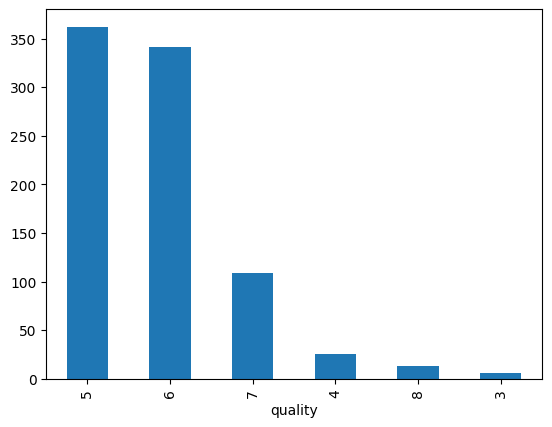

In [11]:
train["quality"].value_counts().plot(kind="bar")

Dari visualisasi distribusi variabel target quality, terlihat bahwa data tidak tersebar secara merata pada seluruh kelas.

Sebagian besar sampel wine berada pada kelas 5 dan 6, dengan jumlah yang jauh lebih dominan dibandingkan kelas lainnya. Sementara itu, kelas dengan kualitas rendah seperti 3 dan 4, serta kelas kualitas tinggi seperti 8, memiliki jumlah data yang sangat sedikit.

In [13]:
X = train.drop(columns=["quality", "Id"])
y = train["quality"]

X_test = test.drop(columns=["Id"])

In [17]:
X.head()
y.head()
X_test.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000


Dataset dipisahkan menjadi fitur (X), target (y), dan data testing (X_test). Fitur digunakan sebagai input model, target sebagai label prediksi, sedangkan data testing digunakan untuk menghasilkan prediksi akhir tanpa label.

In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
# ALASAN PEMILIHAN MODEL
# Random Forest dipilih karena:
# 1. Mampu menangani data non-linear
# 2. Robust terhadap noise dan outlier
# 3. Tidak memerlukan normalisasi data
# 4. Cocok untuk data tabular seperti dataset wine quality
# 5. Memiliki performa yang baik pada klasifikasi multi-class

In [28]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

class_weights

{np.int64(3): np.float64(22.833333333333332),
 np.int64(4): np.float64(5.436507936507937),
 np.int64(5): np.float64(0.395040369088812),
 np.int64(6): np.float64(0.4181929181929182),
 np.int64(7): np.float64(1.3122605363984674),
 np.int64(8): np.float64(11.416666666666666)}

Hasil `class_weights` tersebut menunjukkan bahwa data yang di gunakan memiliki ketidakseimbangan kelas yang cukup signifikan pada variabel target quality. Kelas dengan nilai 5 dan 6 memiliki bobot yang paling kecil, yaitu sekitar 0.395 dan 0.418, yang berarti kedua kelas ini paling banyak muncul dalam data training sehingga dianggap sebagai kelas mayoritas. Sementara itu, kelas 7 memiliki bobot sekitar 1.31 yang menunjukkan bahwa jumlah datanya lebih sedikit dibanding kelas 5 dan 6, namun masih berada pada kategori menengah. Selanjutnya, kelas 4 memiliki bobot sekitar 5.44 yang menandakan bahwa kelas ini sudah tergolong jarang muncul dalam dataset. Kondisi yang lebih ekstrem terlihat pada kelas 8 dengan bobot sekitar 11.41 dan kelas 3 dengan bobot paling tinggi yaitu sekitar 22.83, yang menunjukkan bahwa kedua kelas tersebut sangat jarang muncul atau termasuk kelas minoritas ekstrem.

Secara keseluruhan, hasil ini menggambarkan bahwa distribusi data tidak merata, di mana sebagian besar observasi terkonsentrasi pada kelas 5 dan 6, sedangkan kelas-kelas dengan nilai ekstrem seperti 3, 4, dan 8 memiliki jumlah sampel yang jauh lebih sedikit. Ketidakseimbangan ini berpotensi membuat model lebih condong untuk memprediksi kelas mayoritas jika tidak dilakukan penanganan. Oleh karena itu, penggunaan `class_weight="balanced"` bertujuan untuk memberikan penalti yang lebih besar pada kesalahan prediksi kelas minoritas sehingga model dapat lebih adil dalam mempelajari seluruh kelas dan tidak hanya berfokus pada kelas yang dominan.


In [29]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=800,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight=class_weights,
    random_state=42
)

In [30]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight={np.int64(3): np.float64(22.833333333333332),
                                     np.int64(4): np.float64(5.436507936507937),
                                     np.int64(5): np.float64(0.395040369088812),
                                     np.int64(6): np.float64(0.4181929181929182),
                                     np.int64(7): np.float64(1.3122605363984674),
                                     np.int64(8): np.float64(11.416666666666666)},
                       max_depth=25, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=800, random_state=42)

Output tersebut menunjukkan bahwa model Random Forest Classifier berhasil dilatih dengan konfigurasi hyperparameter yang sudah kamu tentukan, termasuk penggunaan `class_weight` untuk mengatasi ketidakseimbangan data. Model ini dibangun menggunakan 800 pohon keputusan (`n_estimators=800`) yang bertujuan untuk meningkatkan stabilitas dan akurasi prediksi melalui proses ensemble. Kedalaman maksimum pohon dibatasi hingga 25 (`max_depth=25`) agar model tidak terlalu kompleks dan mengurangi risiko overfitting. Selain itu, setiap percabangan minimal membutuhkan 4 sampel untuk melakukan split (`min_samples_split=4`), dan setiap leaf node minimal berisi 2 sampel (`min_samples_leaf=2`) untuk menjaga generalisasi model. Parameter `max_features="sqrt"` berarti setiap split hanya mempertimbangkan akar kuadrat dari jumlah fitur, yang membantu meningkatkan variasi antar pohon dalam ensemble.

Penggunaan `class_weight` yang sudah dihitung sebelumnya menunjukkan bahwa model secara eksplisit diberi perhatian lebih besar terhadap kelas-kelas yang jarang muncul, seperti kelas 3, 4, dan 8, dibandingkan kelas yang dominan seperti 5 dan 6. Hal ini membuat model tidak bias terhadap kelas mayoritas dan lebih mampu mengenali pola dari kelas minoritas. Setelah proses konfigurasi tersebut, model kemudian dilatih menggunakan data training (`X_train` dan `y_train`), sehingga menghasilkan model Random Forest yang sudah teroptimasi baik dari sisi kompleksitas pohon maupun penanganan ketidakseimbangan kelas.


In [31]:
y_pred = model.predict(X_valid)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_valid, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_valid, y_pred))
print("\nClassification Report:\n", classification_report(y_valid, y_pred))

Accuracy: 0.6104651162790697

Confusion Matrix:
 [[ 0  0  0  1  0  0]
 [ 1  0  4  0  0  0]
 [ 1  1 55 15  1  0]
 [ 0  0 21 42  5  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  0  2  1]]

Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.69      0.75      0.72        73
           6       0.58      0.62      0.60        68
           7       0.47      0.32      0.38        22
           8       1.00      0.33      0.50         3

    accuracy                           0.61       172
   macro avg       0.45      0.34      0.37       172
weighted avg       0.60      0.61      0.60       172



Hasil evaluasi model Random Forest menunjukkan bahwa akurasi yang diperoleh sebesar 0.6104 atau sekitar 61%. Ini berarti model mampu memprediksi dengan benar sekitar 61% dari total data validasi. Namun, jika dilihat lebih dalam melalui confusion matrix dan classification report, performa model masih sangat dipengaruhi oleh ketidakseimbangan data antar kelas.

Pada confusion matrix terlihat bahwa model paling baik dalam mengenali kelas 5 dan 6, yang memang merupakan kelas dominan dalam dataset. Kelas 5 memiliki banyak prediksi benar yaitu 55 dari 73 data, sedangkan kelas 6 juga cukup baik dengan 42 prediksi benar dari 68 data. Hal ini menunjukkan bahwa model sudah cukup mampu mempelajari pola pada kelas mayoritas. Namun, pada kelas minoritas seperti 3, 4, dan 8, performa model sangat lemah. Kelas 3 dan 4 bahkan tidak dapat diprediksi dengan baik (precision dan recall 0), sedangkan kelas 8 hanya berhasil dikenali sebagian kecil (recall 0.33), yang menunjukkan bahwa model masih kesulitan mengenali pola dari kelas yang jarang muncul.

Dari classification report, terlihat bahwa nilai precision, recall, dan F1-score untuk kelas 5 dan 6 masih tergolong cukup baik, masing-masing berada di kisaran 0.58–0.72. Namun untuk kelas minoritas, nilainya sangat rendah bahkan nol pada beberapa kelas, yang menunjukkan bahwa model cenderung bias ke kelas mayoritas meskipun sudah menggunakan class weighting. Nilai macro average yang rendah (sekitar 0.34 untuk recall dan 0.37 untuk F1-score) juga memperkuat bahwa secara keseluruhan model belum seimbang dalam menangani semua kelas. Sementara itu, weighted average terlihat lebih tinggi karena masih dipengaruhi oleh dominasi kelas 5 dan 6 dalam data.

Secara keseluruhan, model sudah cukup baik dalam memprediksi kelas yang dominan, tetapi masih kurang optimal dalam menangani kelas minoritas. Hal ini umum terjadi pada data yang tidak seimbang, sehingga meskipun akurasi terlihat cukup baik, performa sebenarnya pada seluruh kelas masih perlu ditingkatkan agar model lebih adil dan robust dalam melakukan klasifikasi.


In [32]:
model.fit(X, y)

RandomForestClassifier(class_weight={np.int64(3): np.float64(22.833333333333332),
                                     np.int64(4): np.float64(5.436507936507937),
                                     np.int64(5): np.float64(0.395040369088812),
                                     np.int64(6): np.float64(0.4181929181929182),
                                     np.int64(7): np.float64(1.3122605363984674),
                                     np.int64(8): np.float64(11.416666666666666)},
                       max_depth=25, min_samples_leaf=2, min_samples_split=4,
                       n_estimators=800, random_state=42)

Kode model.fit(X, y) artinya model Random Forest kamu dilatih ulang menggunakan seluruh data yang ada, bukan hanya data training seperti sebelumnya. Jadi sekarang model mempelajari semua pola dari fitur X dan target y sekaligus untuk membentuk model akhir yang siap dipakai untuk prediksi data baru.

Dari outputnya, terlihat bahwa model tetap memakai setting yang sama seperti sebelumnya, yaitu 800 pohon keputusan, kedalaman maksimum 25, serta aturan pembagian dan jumlah minimum sampel di setiap node. Selain itu, class_weight juga tetap digunakan, sehingga kelas yang jarang muncul seperti 3, 4, dan 8 tetap diberi “bobot perhatian” lebih besar dibanding kelas yang sering muncul seperti 5 dan 6.

Intinya, ini adalah tahap akhir pelatihan model sebelum digunakan untuk prediksi sebenarnya. Tapi perlu diingat, karena model dilatih menggunakan seluruh data, hasil evaluasi di data yang sama tidak lagi bisa dipakai untuk mengukur performa secara adil, karena model sudah “melihat” semua data sebelumnya.

In [33]:
pred_test = model.predict(X_test)
pred_test

array([5, 6, 5, 5, 6, 6, 5, 5, 6, 5, 7, 7, 6, 6, 5, 5, 6, 5, 5, 7, 8, 6,
       5, 7, 5, 5, 7, 6, 5, 6, 6, 6, 7, 6, 5, 5, 6, 6, 7, 6, 7, 6, 6, 5,
       5, 5, 5, 6, 5, 6, 7, 5, 6, 7, 6, 6, 6, 6, 6, 5, 5, 6, 6, 7, 6, 6,
       7, 5, 5, 5, 6, 6, 5, 6, 5, 5, 5, 6, 5, 6, 5, 6, 6, 5, 5, 6, 5, 5,
       6, 6, 5, 6, 5, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5, 6, 6, 6, 7,
       7, 5, 5, 6, 5, 5, 6, 6, 6, 5, 5, 5, 5, 6, 5, 5, 6, 6, 5, 6, 5, 5,
       7, 6, 7, 5, 5, 5, 6, 6, 7, 5, 5, 5, 6, 5, 5, 5, 5, 5, 7, 5, 6, 5,
       6, 5, 5, 5, 7, 6, 5, 5, 6, 6, 7, 5, 6, 6, 6, 5, 6, 5, 6, 5, 5, 5,
       7, 6, 6, 5, 6, 6, 6, 5, 5, 5, 7, 5, 6, 6, 6, 6, 7, 5, 6, 6, 5, 6,
       7, 6, 6, 6, 5, 5, 7, 7, 5, 5, 6, 6, 5, 6, 6, 6, 5, 6, 6, 5, 7, 5,
       5, 6, 5, 5, 5, 6, 6, 6, 6, 6, 8, 7, 5, 5, 6, 7, 5, 6, 5, 5, 7, 6,
       6, 5, 5, 6, 5, 6, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 5, 6, 7, 6,
       5, 5, 6, 6, 5, 6, 6, 7, 5, 6, 5, 6, 5, 6, 5, 5, 5, 6, 5, 5, 6, 7])

Hasil prediksi model pada data testing menunjukkan bahwa nilai kualitas wine yang diprediksi berada pada rentang 5 hingga 8. Distribusi prediksi didominasi oleh kelas 5 dan 6, yang menunjukkan bahwa model cenderung mengklasifikasikan sebagian besar sampel wine sebagai kualitas menengah.

Kelas dengan kualitas lebih tinggi seperti 7 dan 8 muncul dalam jumlah yang lebih sedikit, sedangkan kelas dengan kualitas rendah tidak banyak muncul dalam hasil prediksi. Hal ini konsisten dengan pola pada data training, di mana kelas 5 dan 6 merupakan kelas yang paling dominan.

Dominasi prediksi pada kelas tertentu menunjukkan bahwa model masih cenderung bias terhadap kelas mayoritas, meskipun telah dilakukan penanganan ketidakseimbangan data menggunakan parameter class_weight pada Random Forest. Namun demikian, hasil ini masih dapat diterima karena model tetap mampu menghasilkan prediksi yang konsisten dengan pola distribusi data asli.

In [34]:
submission = pd.DataFrame({
    "Id": test["Id"],
    "quality": pred_test
})

submission.to_csv("hasilprediksi_3NIMterakhir.csv", index=False)

In [38]:
submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,6


In [39]:
import os
os.listdir()

['.config',
 'data_testing.csv',
 'data_training.csv',
 'hasilprediksi_3NIMterakhir.csv',
 'sample_data']

In [43]:
from google.colab import files
files.download("hasilprediksi_3NIMterakhir.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>